In [277]:
# 06/2025
# Pre: shape files (isomap ONLY) already generated
###########################################################################################
# Load the subject information and the shape information
# statistical tests:
#   normality tests for all and by hemisphere
#   T-test or Mann-Whitney U (Wilcoxon ranksum), all together and by separate hemisphere as well
#   plots

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import kruskal
import statsmodels.api as sm
import statsmodels.formula.api as smf 
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
curRegion = 'Calc'
curRoot = 'C'  # 'C' or 'D'

In [5]:
#######################  Helper function to load patient control info  #########################

def load_patientControlInfo_CADASIL(curRoot, filename="patients_controls_table.csv"):
    """
    Loads and processes the CADASIL info table.

    Parameters
    ----------
    curRoot : str
        Root path where the data is stored.
    filename : str, optional
        Name of the CSV file (default: 'patients_controls_table.csv').

    Returns
    -------
    pd.DataFrames
        Processed CADASIL dataframe with 'subjName' as index and 'Category_num' column.
        Returns None if file not found.
    """
    CADASIL_info_path = rf"{curRoot}:\B_projWIP\proj_CADASIL\{filename}"
    
    try:
        CADASIL_info = pd.read_csv(CADASIL_info_path, index_col=0, header=0, sep=";")
    except FileNotFoundError as e:
        print(f"Error: {e}")
        return None
    
    # Reset index to make old index 'Subject' a column
    CADASIL_info.reset_index(inplace=True)

    # Step 1: Append '_1' to Subject if it contains '74', '75', or '76'
    CADASIL_info['Subject'] = CADASIL_info['Subject'].astype(str).apply(
        lambda x: x + '_1' if any(substr in x for substr in ['74', '75', '76']) else x
    )
    
    # Step 2: Create 'subjName' and set it as index
    CADASIL_info['subjName'] = (
        'rv_BIOMRI_CADA_001_' +
        CADASIL_info['Subject'].str.replace('-', '_') +
        '_S3_3DT1_mprage_1iso_ipat2'
    )
    CADASIL_info.set_index('subjName', inplace=True)

    # Step 3: Create numeric category
    CADASIL_info['Category_num'] = CADASIL_info['Category'].map({'Control': 0, 'Patient': 1})

    return CADASIL_info

In [9]:
##################################### Prepare Patient/Control infomation ####################################
# Note: this is needed to filter the distance matrix
CADASIL_info = load_patientControlInfo_CADASIL(curRoot)

# Start with your processed metadata
df = CADASIL_info.copy()

# First duplicate with "L"
df_L = df.copy()
df_L.index = "L" + df_L.index.astype(str)

# Second duplicate with "flip-R"
df_R = df.copy()
df_R.index = "flip-R" + df_R.index.astype(str)

# Concatenate all together
CADASIL_info_doubled = pd.concat([df_L, df_R], axis=0)

print(CADASIL_info_doubled.head())
print(CADASIL_info_doubled.tail())
print(len(CADASIL_info), "original rows →", len(CADASIL_info_doubled), "after doubling")

CADASIL_info = CADASIL_info_doubled

                                                   Subject Category  \
subjName                                                              
Lrv_BIOMRI_CADA_001_012_TE_S3_3DT1_mprage_1iso_...  012-TE  Patient   
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...  017-LE  Patient   
Lrv_BIOMRI_CADA_001_019_JM_S3_3DT1_mprage_1iso_...  019-JM  Patient   
Lrv_BIOMRI_CADA_001_020_FJ_S3_3DT1_mprage_1iso_...  020-FJ  Patient   
Lrv_BIOMRI_CADA_001_024_ZT_S3_3DT1_mprage_1iso_...  024-ZT  Patient   

                                                    Category_num  
subjName                                                          
Lrv_BIOMRI_CADA_001_012_TE_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_019_JM_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_020_FJ_S3_3DT1_mprage_1iso_...             1  
Lrv_BIOMRI_CADA_001_024_ZT_S3_3DT1_mprage_1iso_...             1  
                                 

In [15]:
#######################  Load isomap shape information  #######################
shape = None
shape_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Oct_2025\isomapCmds{curRegion}k10d3distmin_keepOut_oriSulci_all.txt'

try:
    shape = pd.read_csv(shape_path, index_col=0, header=0)

    # Rename columns
    rename_dict = {'1': 'iso1', '2': 'iso2', '3': 'iso3'}
    shape.rename(columns=rename_dict, inplace=True)
    print(shape.head())
    print(shape.index)

except FileNotFoundError as e:
    print(f"Error: {e}")

                                                        iso1      iso2  \
subjName                                                                 
Lrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_... -4.259947 -0.806934   
Lrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1is... -1.420259  2.351087   
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_... -5.309101 -1.034200   
Lrv_BIOMRI_CADA_001_070_PC_S3_3DT1_mprage_1iso_...  1.270277  0.698478   
Lrv_BIOMRI_CADA_001_025_GF_S3_3DT1_mprage_1iso_... -0.613341 -0.546946   

                                                        iso3  
subjName                                                      
Lrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_...  0.931322  
Lrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1is...  4.742367  
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_...  2.109876  
Lrv_BIOMRI_CADA_001_070_PC_S3_3DT1_mprage_1iso_... -3.196041  
Lrv_BIOMRI_CADA_001_025_GF_S3_3DT1_mprage_1iso_... -2.516755  
Index(['Lrv_BIOMRI_CADA_001_072_LJ_S3_3D

In [17]:
##################################### Prepare morphometric infomation ####################################
# Load distance measures
curRoot = 'C'  # 'C' or 'D'
curRegionLeft = 'F.Cal.ant.-Sc.Cal._left' # 'S.C.sylvian._left'
curRegionRight = 'F.Cal.ant.-Sc.Cal._right' # 'S.C.sylvian._right'

path_left = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curRegionLeft}.csv'
path_right = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\{curRegionRight}.csv'
try:
    left = pd.read_csv(path_left, index_col=0, header=0, sep=';')
    right = pd.read_csv(path_right, index_col=0, header=0, sep=';')    
except FileNotFoundError as e:
    print(f"Error: {e}")

# adding side info to the index and remove the 'side' column
left.index = 'L' + left.index
right.index = 'flip-R' + right.index
del left['side']
del right['side']
Morpho_measures = pd.concat([left,right],axis=0)


In [19]:
##################################### Merge morphometric and shape infomation ####################################
combined_measures = pd.merge(Morpho_measures, shape, left_index=True, right_index=True)
shape = combined_measures

In [21]:
print(shape.columns)

Index(['label', 'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3'],
      dtype='object')


In [23]:
##################################### Prepare Database-specific infomation ####################################
CADASIL_info = load_patientControlInfo_CADASIL(curRoot)
print(len(CADASIL_info))

34


In [25]:
################### Double Database-specific infomation to account for the two hemisphere ##################
CADASIL_info_L = CADASIL_info.copy()
CADASIL_info_flip_R = CADASIL_info.copy()

# Append 'L' to the index of the first copy
CADASIL_info_L.index = 'L' + CADASIL_info_L.index
# Add a column side
CADASIL_info_L['side'] = 'L'

# Append 'flip_R' to the index of the second copy
CADASIL_info_flip_R.index = 'flip-R' + CADASIL_info_flip_R.index
# Add a column side
CADASIL_info_flip_R['side'] = 'R'

# Compose the new info df with the new index
CADASIL_info_LR_combined = pd.concat([CADASIL_info_L, CADASIL_info_flip_R])
print(len(CADASIL_info_LR_combined))

##############################  Join INFO with shape measures  ################################
#desired_columns = ['iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 

# Inner join on index, selecting desired columns from df2
#complete_info_CADASIL = CADASIL_info_LR_combined.merge(shape[desired_columns], how='inner', left_index=True, right_index=True)
complete_info_CADASIL = CADASIL_info_LR_combined.merge(shape, how='inner', left_index=True, right_index=True)

print(len(complete_info_CADASIL))

68
68


In [27]:
# Identify the missing indices from the final matrix if there are any
missing_indices = CADASIL_info_LR_combined.index.difference(complete_info_CADASIL.index)

# Display the missing indices
print("Missing indices from the smaller DataFrame (CADASIL_info_LR_combined):")
print(missing_indices)

# Display the rows themselves:
missing_rows = CADASIL_info_LR_combined.loc[missing_indices]
print("Missing rows from the smaller DataFrame (CADASIL_info_LR_combined):")
print(missing_rows)

Missing indices from the smaller DataFrame (CADASIL_info_LR_combined):
Index([], dtype='object')
Missing rows from the smaller DataFrame (CADASIL_info_LR_combined):
Empty DataFrame
Columns: [Subject, Category, Category_num, side]
Index: []


In [292]:
###########################################  Verifications  ###########################################

In [29]:
print(complete_info_CADASIL.columns)

Index(['Subject', 'Category', 'Category_num', 'side', 'label',
       'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3'],
      dtype='object')


In [31]:
ctl_counts = complete_info_CADASIL['Category_num'].value_counts()
print(ctl_counts)

Category_num
1    36
0    32
Name: count, dtype: int64


In [33]:
####################  Display the values of a specific column  ####################
print("Values in the 'iso1' column:")
print(complete_info_CADASIL['iso1'])

####################  Display the rows with a specific column value  ####################
cer = complete_info_CADASIL[complete_info_CADASIL['Category'] == 'Patient']
#print(cer['Category'])

####################  Get a summary of statistics  ####################
summary_stats = complete_info_CADASIL['iso1'].describe()
print("\nSummary statistics for the 'isomap1' column:")
print(summary_stats)

####################  Detect null values in a specific column  ###################
null_values = complete_info_CADASIL['Category'].isnull()
#print(null_values)

####################  Filter rows where the specified column has null values  #####################
null_rows = complete_info_CADASIL[complete_info_CADASIL['iso1'].isnull()]
#print(null_rows['1'])

####################  Count the number of null values in a specific column  ######################
null_count = complete_info_CADASIL['iso1'].isnull().sum()
print(f"Number of null values in selected column: {null_count}")


Values in the 'iso1' column:
Lrv_BIOMRI_CADA_001_012_TE_S3_3DT1_mprage_1iso_ipat2           2.392187
Lrv_BIOMRI_CADA_001_017_LE_S3_3DT1_mprage_1iso_ipat2          -5.309101
Lrv_BIOMRI_CADA_001_019_JM_S3_3DT1_mprage_1iso_ipat2          -5.457574
Lrv_BIOMRI_CADA_001_020_FJ_S3_3DT1_mprage_1iso_ipat2          -4.317406
Lrv_BIOMRI_CADA_001_024_ZT_S3_3DT1_mprage_1iso_ipat2          -5.393818
                                                                 ...   
flip-Rrv_BIOMRI_CADA_001_071_BV_S3_3DT1_mprage_1iso_ipat2      2.027872
flip-Rrv_BIOMRI_CADA_001_072_LJ_S3_3DT1_mprage_1iso_ipat2     -3.051799
flip-Rrv_BIOMRI_CADA_001_074_RL_1_S3_3DT1_mprage_1iso_ipat2    3.354968
flip-Rrv_BIOMRI_CADA_001_075_JA_1_S3_3DT1_mprage_1iso_ipat2    3.229979
flip-Rrv_BIOMRI_CADA_001_076_BS_1_S3_3DT1_mprage_1iso_ipat2    7.768821
Name: iso1, Length: 68, dtype: float64

Summary statistics for the 'isomap1' column:
count    6.800000e+01
mean    -7.836868e-17
std      3.464646e+00
min     -6.920496e+00
25%   

In [37]:
################################  Saving csv files if needed  #################################

file_path = rf'{curRoot}:\B_projWIP\proj_CADASIL\Oct_2025\isomapCmdsCalck10d3distmin_keepOut_oriSulci_all_info.csv'
print(file_path)

# Write the DataFrame to a CSV file
#complete_info_CADASIL.to_csv(file_path, index=True)

################################  Test read the CSV file back into a DataFrame  ################################
#df_loaded = pd.read_csv(file_path)
#print(len(df_loaded))
#print("Data types:\n", df_loaded.dtypes)

C:\B_projWIP\proj_CADASIL\Oct_2025\isomapCmdsCalck10d3distmin_keepOut_oriSulci_all_info.csv


In [297]:
###################################################  Stats  ###################################################

In [39]:
######################  define composing combined_L, combined_R  ###################### 
combined = complete_info_CADASIL

combined_L = combined[combined['side'] == 'L']
combined_R = combined[combined['side'] == 'R']
#combined_L = combined[combined.index.str.startswith('L')]
#combined_R = combined[combined.index.str.startswith('flip')]
#print(len(combined_L))

In [43]:
##############################  Testing Normality, all together  ###############################
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
from scipy.stats import shapiro

print('Shapiro-Wilk test for normality: combined')

curMeasure = 'iso1'
stat, p_value = shapiro(combined[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

Shapiro-Wilk test for normality: combined
iso1 p-val: 0.6801479227052467
iso2 p-val: 0.6693620536994744
iso3 p-val: 0.7015391199919758


"\ncurMeasure = 'UMAP1_U1'\nstat, p_value = shapiro(combined[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n\ncurMeasure = 'UMAP1_U2'\nstat, p_value = shapiro(combined[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n\ncurMeasure = 'UMAP1_U3'\nstat, p_value = shapiro(combined[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n\ncurMeasure = 'UMAP2_U3'\nstat, p_value = shapiro(combined[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n\ncurMeasure = 'UMAP1_U4'\nstat, p_value = shapiro(combined[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n\ncurMeasure = 'UMAP2_U4'\nstat, p_value = shapiro(combined[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n"

In [45]:
#########################  Testing Normality, Left hemisphere  ##########################
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
from scipy.stats import shapiro

print('Shapiro-Wilk test for normality: combined_L')
curMeasure = 'iso1'
stat, p_value = shapiro(combined_L[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

Shapiro-Wilk test for normality: combined_L
iso1 p-val: 0.6192113489664606
iso2 p-val: 0.5584056053906592
iso3 p-val: 0.8744941951682315


"\ncurMeasure = 'UMAP1_U1'\nstat, p_value = shapiro(combined_L[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP1_U2'\nstat, p_value = shapiro(combined_L[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP1_U3'\nstat, p_value = shapiro(combined_L[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP2_U3'\nstat, p_value = shapiro(combined_L[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP1_U4'\nstat, p_value = shapiro(combined_L[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP2_U4'\nstat, p_value = shapiro(combined_L[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n"

In [49]:
#########################  Testing Normality, Right hemisphere  ##########################
# Shapiro-Wilk test for normality, not normally distributed if p-val < 0.05
from scipy.stats import shapiro

print('Shapiro-Wilk test for normality: combined_R')
curMeasure = 'iso1'
stat, p_value = shapiro(combined_R[curMeasure])
print(f'{curMeasure} p-val: {p_value}')

Shapiro-Wilk test for normality: combined_R
iso1 p-val: 0.6431843733975392
iso2 p-val: 0.3733703571989914
iso3 p-val: 0.283142296579024


"\ncurMeasure = 'UMAP1_U1'\nstat, p_value = shapiro(combined_R[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP1_U2'\nstat, p_value = shapiro(combined_R[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP1_U3'\nstat, p_value = shapiro(combined_R[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP2_U3'\nstat, p_value = shapiro(combined_R[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP1_U4'\nstat, p_value = shapiro(combined_R[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\ncurMeasure = 'UMAP2_U4'\nstat, p_value = shapiro(combined_R[curMeasure])\nprint(f'{curMeasure} p-val: {p_value}')\n"

In [65]:
#############################  comparing patients vs. controls on a given shape descriptor  ##############################
measure = 'iso1'

# Subset the data
patients = combined[combined['Category_num'] == 1][measure]
controls = combined[combined['Category_num'] == 0][measure]

#############################  comparing patients vs. controls on a shape descriptor  ##############################

#################  T-test (parametric)  ##################
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(patients, controls, equal_var=False) # Welch's t-test is safer, not assuming equal variance
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print()

#################  Mann–Whitney U test (nonparametric)  #################
from scipy.stats import mannwhitneyu
u_stat, p_val = mannwhitneyu(patients, controls, alternative='two-sided')
# Print the results
print(f"U statistic: {u_stat:.4f}")
print(f"p-value: {p_val:.4f}")
print()

###############  testing association/correlation with classification (0 = control, 1 = patient)  ###############

#################  Point-Biserial Correlation  #################
# Measures the correlation between a binary variable and a continuous variable
from scipy.stats import pointbiserialr
#pointbiserialr(combined['Category_num'], combined[measure])
# Run point-biserial correlation
r, p_val = pointbiserialr(combined['Category_num'], combined[measure])

# Print the results
print(f"Correlation coefficient (r): {r:.4f}")
print(f"p-value: {p_val:.4f}")
print()

#################  Logistic regression  #################
# test how well the shape descriptor predicts patient/control classification
import statsmodels.api as sm

X = sm.add_constant(combined[measure])  # Add intercept
y = combined['Category_num']  # 0 or 1
model = sm.Logit(y, X).fit()
print(model.summary())


t-statistic: -2.0614
p-value: 0.0433

U statistic: 413.0000
p-value: 0.0459

Correlation coefficient (r): -0.2420
p-value: 0.0468

Optimization terminated successfully.
         Current function value: 0.661420
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:           Category_num   No. Observations:                   68
Model:                          Logit   Df Residuals:                       66
Method:                           MLE   Df Model:                            1
Date:                Fri, 31 Oct 2025   Pseudo R-squ.:                 0.04338
Time:                        11:44:35   Log-Likelihood:                -44.977
converged:                       True   LL-Null:                       -47.016
Covariance Type:            nonrobust   LLR p-value:                   0.04341
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------

In [303]:
print(combined.columns)

Index(['Subject', 'Category', 'Category_num', 'side', 'label',
       'surface_talairach', 'surface_native', 'maxdepth_talairach',
       'maxdepth_native', 'meandepth_talairach', 'meandepth_native',
       'hull_junction_length_talairach', 'hull_junction_length_native',
       'GM_thickness', 'opening', 'iso1', 'iso2', 'iso3', 'UMAP1_U1',
       'UMAP1_U2', 'UMAP1_U3', 'UMAP2_U3', 'UMAP1_U4', 'UMAP2_U4'],
      dtype='object')


In [304]:
#############################  comparing patients vs. controls on multiple shape descriptors  ##############################
#'surface_talairach', 'surface_native', 'maxdepth_talairach','maxdepth_native', 'meandepth_talairach', 'meandepth_native'
#'hull_junction_length_talairach', 'hull_junction_length_native','GM_thickness', 'opening' 

#shape_features = ['iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4'] 
shape_features = ['iso1', 'iso2', 'iso3','UMAP1_U1','UMAP1_U2','UMAP1_U3','UMAP2_U3','UMAP1_U4','UMAP2_U4',
                  'surface_talairach', 'surface_native', 
                  'maxdepth_talairach','maxdepth_native', 
                  'meandepth_talairach', 'meandepth_native',
                  'hull_junction_length_talairach', 'hull_junction_length_native',
                  'GM_thickness', 'opening'
                 ]
curTest = 'mwu' # t, mwu

def testDiff(curDF,curTest):
    results = {}
    for feat in shape_features:
        patients = curDF[curDF['Category_num'] == 1][feat]
        controls = curDF[curDF['Category_num'] == 0][feat]    
        if (curTest == 't'):     # t-test
            t_stat, p_val = ttest_ind(patients, controls, equal_var=False)
            results[feat] = p_val
        if (curTest == 'mwu'):     # Mann-Whitney U
            u_stat, p_val = mannwhitneyu(patients, controls, alternative='two-sided')
            results[feat] = p_val
    print(results)

curTest = 'mwu' # t, mwu
testDiff(combined,curTest)
print()
testDiff(combined_L,curTest)
print()
testDiff(combined_R,curTest)

{'iso1': 0.0016936065304330795, 'iso2': 0.6716419357264423, 'iso3': 0.9559068444243249, 'UMAP1_U1': 0.01801962047106347, 'UMAP1_U2': 0.006997586134970774, 'UMAP1_U3': 0.8876341019162762, 'UMAP2_U3': 0.00580862711650354, 'UMAP1_U4': 0.0011545921601433383, 'UMAP2_U4': 0.8973483817314564, 'surface_talairach': 0.38636870931057676, 'surface_native': 0.38636870931057676, 'maxdepth_talairach': 0.07185739374103652, 'maxdepth_native': 0.07381347142107511, 'meandepth_talairach': 0.24063854990539701, 'meandepth_native': 0.24559453146672827, 'hull_junction_length_talairach': 0.6671642582796388, 'hull_junction_length_native': 0.6761253807659011, 'GM_thickness': nan, 'opening': nan}

{'iso1': 0.028454821001272775, 'iso2': 0.7958091685190174, 'iso3': 0.39792644246181264, 'UMAP1_U1': 0.002014790592028934, 'UMAP1_U2': 0.007495154802504972, 'UMAP1_U3': 0.7430771478039212, 'UMAP2_U3': 0.012367275486607826, 'UMAP1_U4': 0.014995774249597058, 'UMAP2_U4': 1.0, 'surface_talairach': 0.4375578509038419, 'surfac

C:\Users\joyca\AppData\Local\Temp\ipykernel_2216\1136175366.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


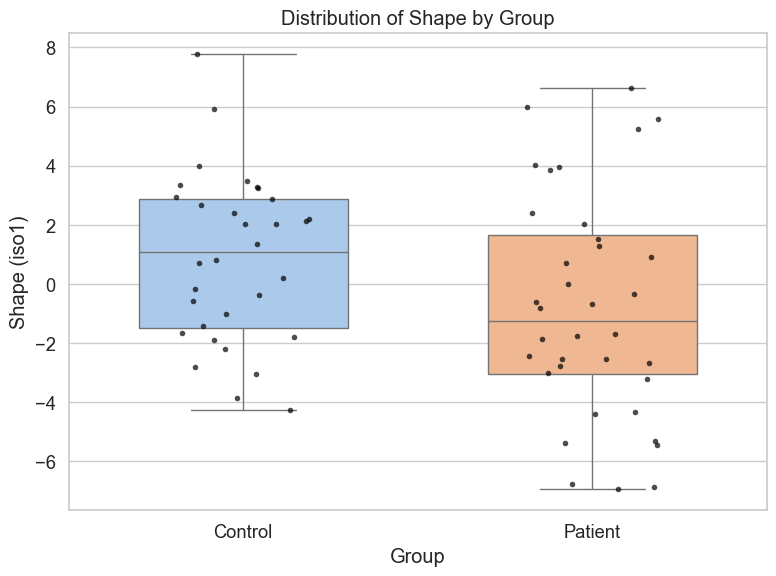

In [53]:
##########################################  boxplot  ##########################################
np.random.seed(42)  # fix the seed so there's no random jitter 

df = combined
order = ['Control','Patient']  # specify desired order
# Set a clean, publication-style aesthetic
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(8, 6))

sns.boxplot(
    x="Category",
    y="iso1",
    data=df,
    palette="pastel",
    width=0.6,
    order=order
)

# Overlay individual points
sns.stripplot(
    x="Category",
    y="iso1",
    data=df,
    color="black",
    size=4,
    jitter=0.2,
    alpha=0.7,
    order=order
)

plt.title("Distribution of Shape by Group")
plt.xlabel("Group")
plt.ylabel("Shape (iso1)")
plt.tight_layout()

#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\Plots\iso1_ctl_patient_Box_Distribution.png')
#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\Plots\iso1_ctl_patient_Box_Distribution.png')

#outFileName = rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\umap_remove_2\{outName}'


plt.show()

C:\Users\joyca\AppData\Local\Temp\ipykernel_2216\2150691961.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Category_num', y='iso1', data=df, palette='coolwarm')


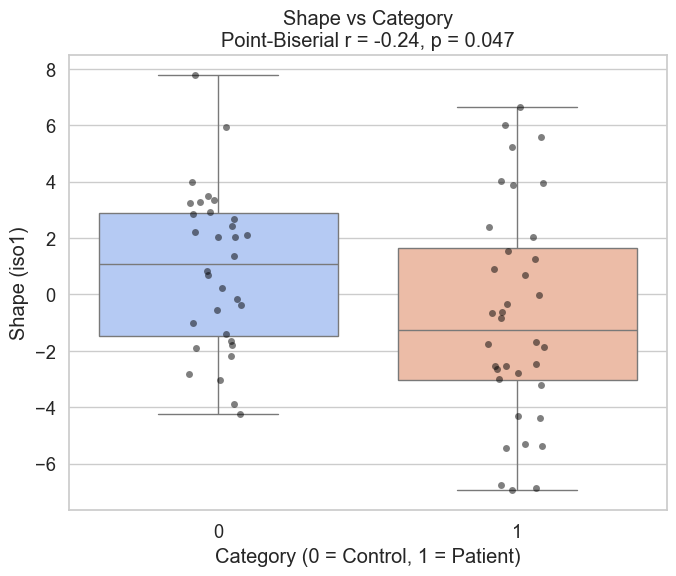

In [55]:
#########################   optional, adding point-biserail information    ############################

from scipy.stats import pointbiserialr

r, p = pointbiserialr(df['Category_num'], df['iso1'])

sns.set(style="whitegrid", font_scale=1.2)
plt.figure(figsize=(7, 6))

sns.boxplot(x='Category_num', y='iso1', data=df, palette='coolwarm')
sns.stripplot(x='Category_num', y='iso1', data=df, color='black', jitter=True, alpha=0.5)

plt.xlabel('Category (0 = Control, 1 = Patient)')
plt.ylabel("Shape (iso1)")
plt.title(f'Shape vs Category\nPoint-Biserial r = {r:.2f}, p = {p:.3f}')
plt.tight_layout()
plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_2216\1346333915.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_L["side"] = "L"
C:\Users\joyca\AppData\Local\Temp\ipykernel_2216\1346333915.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_R["side"] = "R"


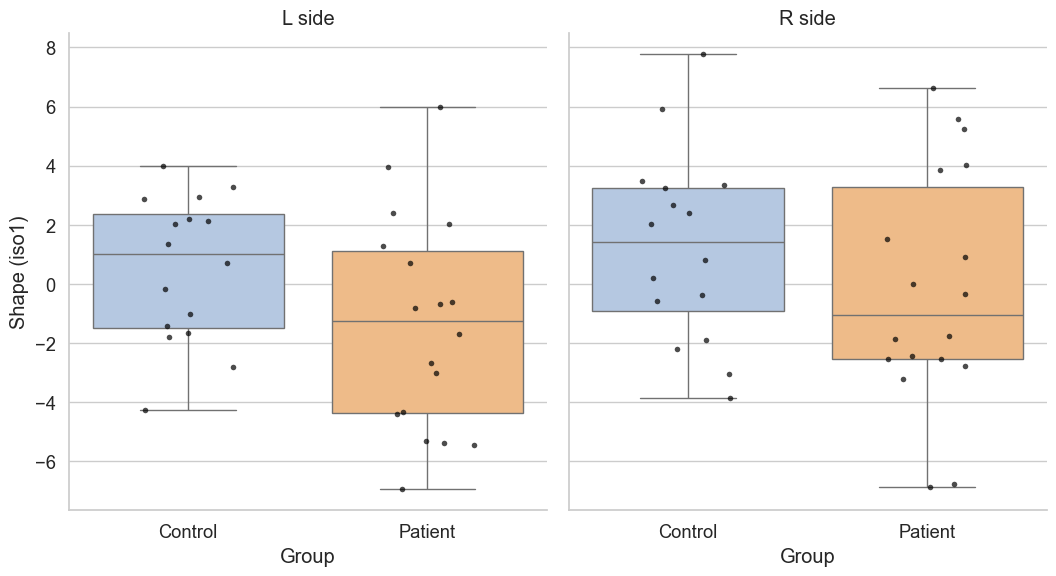

In [57]:
order = ['Control', 'Patient']
#custom_palette = {
#    'Control': '#1f77b4',  # blue
#    'Patient': '#ff7f0e'   # orange
#}
custom_palette = {
    'Control': '#aec7e8',  # pastel blue
    'Patient': '#ffbb78'   # pastel orange
}

combined_L["side"] = "L"
combined_R["side"] = "R"
df_both = pd.concat([combined_L, combined_R])

sns.set(style="whitegrid", font_scale=1.2)

g = sns.catplot(
    data=df_both,
    x="Category",
    y="iso1",
    hue="Category",
    col="side",
    kind="box",
    palette=custom_palette,
    order=order,
    height=6,
    aspect=0.9
)

# Overlay points
for ax, side in zip(g.axes[0], ["L", "R"]):
    sns.stripplot(
        data=df_both[df_both["side"] == side],
        x="Category",
        y="iso1",
        color="black",
        size=4,
        jitter=0.2,
        alpha=0.7,
        order=order,
        ax=ax
    )

g.set_axis_labels("Group", "Shape (iso1)")
g.set_titles("{col_name} side")
plt.tight_layout()

# Save if needed
#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\Plots\iso1_ctl_patient_Box_Hem_Distribution.png')

plt.show()


C:\Users\joyca\AppData\Local\Temp\ipykernel_2216\2665292574.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_L["side"] = "L"
C:\Users\joyca\AppData\Local\Temp\ipykernel_2216\2665292574.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_R["side"] = "R"


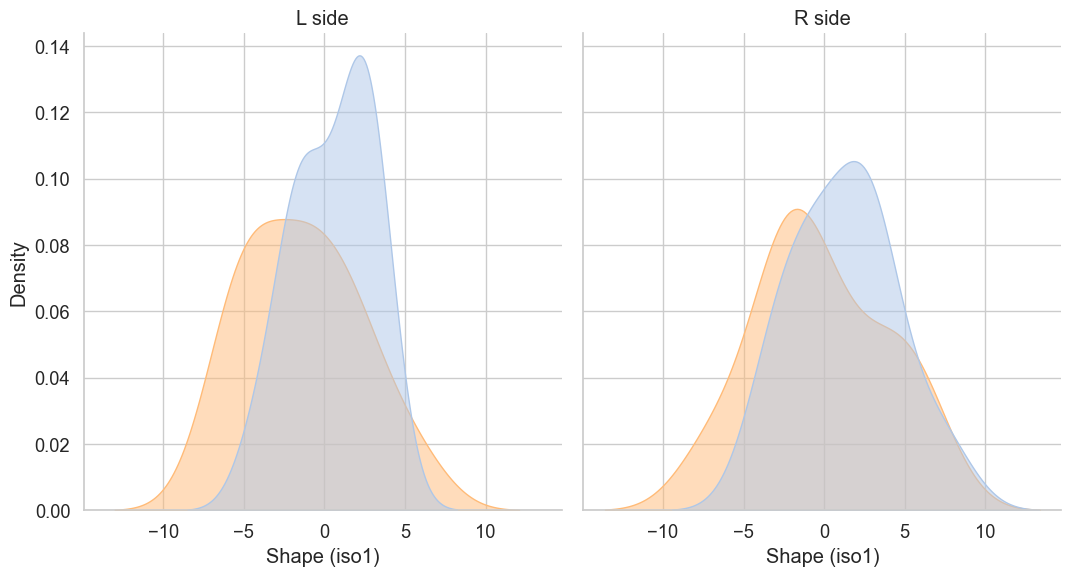

In [59]:
order = ['Control', 'Patient']
custom_palette = {
    'Control': '#aec7e8',  # pastel blue
    'Patient': '#ffbb78'   # pastel orange
}

# Add hemisphere labels
combined_L["side"] = "L"
combined_R["side"] = "R"
df_both = pd.concat([combined_L, combined_R])

sns.set(style="whitegrid", font_scale=1.2)

# Create FacetGrid by hemisphere
g = sns.FacetGrid(df_both, col="side", height=6, aspect=0.9)

# Map kdeplot with controlled hue order and colors
g.map_dataframe(
    sns.kdeplot,
    x="iso1",
    hue="Category",
    hue_order=order,
    palette=custom_palette,
    common_norm=False,
    fill=True,
    alpha=0.5
)

# Titles and labels
g.set_axis_labels("Shape (iso1)", "Density")
g.set_titles("{col_name} side")
g.add_legend()

plt.tight_layout()

# Optional save
#plt.savefig(rf'{curRoot}:\B_projWIP\proj_CADASIL\Analysis\main_piece_analysis\Plots\iso1_ctl_patient_Density_Hem_Distribution.png')

plt.show()
